# Tutorial: Implementing BO through Gpytorch Gaussian Process

## Gaussian Process Surrogate

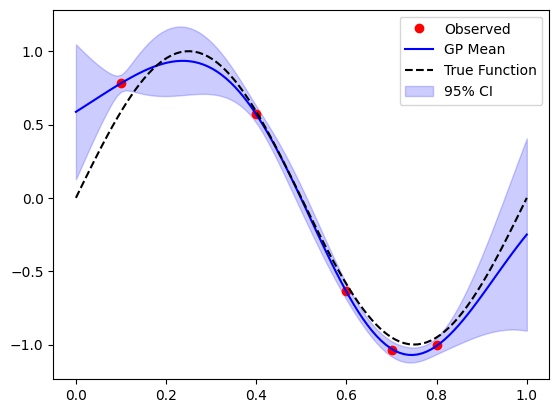

In [7]:
# type: ignore

import torch
import gpytorch
import numpy as np

# Generate synthetic data
X_train = torch.tensor([0.1, 0.4, 0.6, 0.7, 0.8]).unsqueeze(-1)
y_train = torch.sin(2 * np.pi * X_train).squeeze() + 0.1 * torch.randn(X_train.size(0))

# Define GP model
class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Instantiate likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPModel(X_train, y_train, likelihood)

# Training loop
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(100):
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train)
    loss.backward()
    optimizer.step()

# Switch to eval mode for prediction
model.eval()
likelihood.eval()
X_test = torch.linspace(0, 1, 100).unsqueeze(-1)
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = model(X_test)
    y_pred = pred.mean
    y_std = pred.stddev

# Plot results (optional)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(X_train.numpy(), y_train.numpy(), 'ro', label='Observed')
plt.plot(X_test.numpy(), y_pred.numpy(), 'b-', label='GP Mean')
plt.plot(X_test.numpy(), np.sin(2 * np.pi * X_test.numpy()), 'k--', label='True Function')
plt.fill_between(X_test.numpy().ravel(),
                 (y_pred - 2*y_std).numpy(),
                 (y_pred + 2*y_std).numpy(),
                 color='blue', alpha=0.2, label='95% CI')
plt.legend()
plt.show()

## Acquisition Functions

In [8]:
from scipy.stats import norm

def acq_ucb_torch(x, model, beta=2.0):
    """UCB for GPyTorch (x should be torch tensor, shape [N, D])."""
    model.eval()
    with torch.no_grad():
        pred = model(x)
        mu = pred.mean
        std = pred.stddev
        return mu + beta * std

def acq_ei_torch(x, model, y_best, xi=0.0):
    """EI for GPyTorch (returns numpy array)."""
    model.eval()
    with torch.no_grad():
        pred = model(x)
        mu = pred.mean.cpu().numpy()
        std = pred.stddev.cpu().numpy()
        imp = mu - y_best - xi
        with np.errstate(divide='warn'):
            Z = imp / std
            ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
            ei[std == 0.0] = 0.0
        return ei

def acq_pi_torch(x, model, y_best, xi=0.0):
    """PI for GPyTorch (returns numpy array)."""
    model.eval()
    with torch.no_grad():
        pred = model(x)
        mu = pred.mean.cpu().numpy()
        std = pred.stddev.cpu().numpy()
        with np.errstate(divide='warn'):
            Z = (mu - y_best - xi) / std
            pi = norm.cdf(Z)
            pi[std == 0.0] = 0.0
        return pi

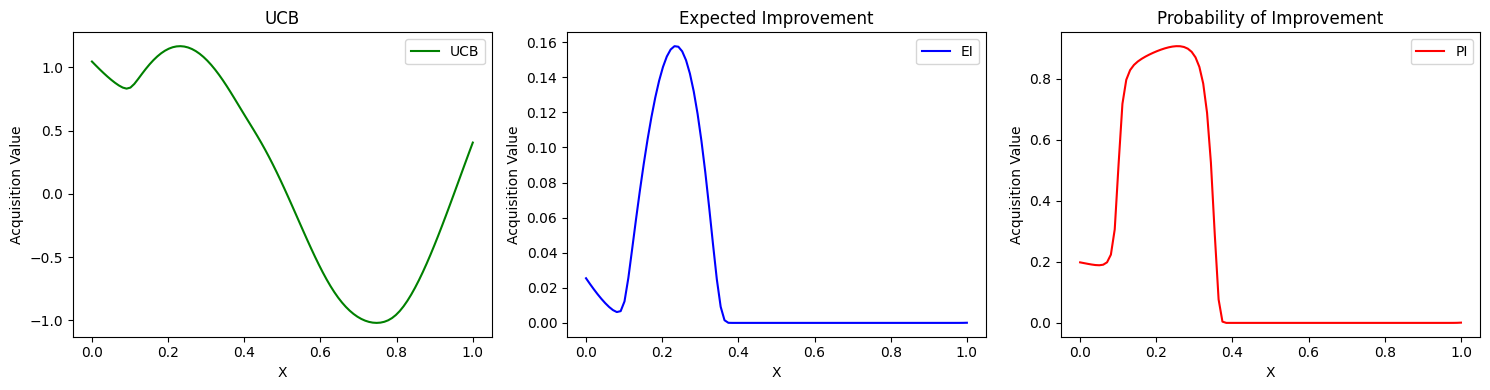

In [9]:
# Plot the acquisition functions.

y_best = y_train.max().item()
ucb = acq_ucb_torch(X_test, model)
ei = acq_ei_torch(X_test, model, y_best)
pi = acq_pi_torch(X_test, model, y_best)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(X_test.numpy(), ucb.numpy(), 'g-', label='UCB')
axs[0].set_title('UCB')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Acquisition Value')
axs[0].legend()

axs[1].plot(X_test.numpy(), ei, 'b-', label='EI')
axs[1].set_title('Expected Improvement')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Acquisition Value')
axs[1].legend()

axs[2].plot(X_test.numpy(), pi, 'r-', label='PI')
axs[2].set_title('Probability of Improvement')
axs[2].set_xlabel('X')
axs[2].set_ylabel('Acquisition Value')
axs[2].legend()

plt.tight_layout()
plt.show()